In [1]:
from datetime import datetime, timedelta

import pandas as pd
import seaborn as sns
from astropy.table import Table
from matplotlib import pyplot as plt

In [2]:
# GPS to UTC time difference due to leap seconds
LEAP_SECONDS = 18  # GPS time is ahead of UTC by 18 seconds (as of 2024)


def gps_to_utc(gps_time):
    """
    Convert GPS time (seconds) to UTC time, accounting for 18 seconds leap second offset.
    Args:
        gps_time (int, float, or np.int64): GPS time in seconds
    Returns:
        datetime: Corresponding UTC time as a datetime object
    """
    gps_epoch = datetime(1980, 1, 6)
    gps_time = int(gps_time)  # Use float(gps_time) if fractional seconds are needed
    utc_time = gps_epoch + timedelta(seconds=gps_time - LEAP_SECONDS)
    return utc_time

### 1. The Cumulative GWTC-4, which contains all the events from O1 to O4  

Source: [GWOSC Event Catalog](https://gwosc.org/eventapi/html/GWTC/)


In [3]:
# Load the cumulative GWTC-4 catalog (O1–O4 events) from local CSV file
cumulative_GWTC4 = Table.read("./data/Cumulative_GWTC-4.0.csv", format="ascii.csv")

In [4]:
# Select only events belonging to the O4a catalog
O4a_events = cumulative_GWTC4[
    (cumulative_GWTC4["catalog"] == "GWTC-4.0") & (cumulative_GWTC4["p_astro"] >= 0.5)
]

# Quick check: display the number of events in O4
print(f"Number of events in O4a: {len(O4a_events)}")

Number of events in O4a: 129



##### `Note on GWTC-4 Catalog`

There appears to be a small discrepancy in the **abstract** of the GWTC-4 catalog ([GWTC-4.0 Results](https://dcc.ligo.org/DocDB/0196/P2400386/012/GWTC-4.0_results_v12.pdf)).  
The document states that the number of events with $p_{\mathrm{astro}} \geq 0.5$ is **128**, whereas by direct counting it should be **129**.  

In practice, the number **128** corresponds to events with $p_{\mathrm{astro}} > 0.5$, while including the equality ($\geq 0.5$) yields **129 events**.  

This difference comes from the candidate **GW230615_160825**, which has $p_{\mathrm{astro}} = 0.5$. If one includes this event, the count is 129;  
if one adopts the strict threshold $p_{\mathrm{astro}} > 0.5$, the count is 128.  


The same value (**128**) is also reported in the LVK *Rates & Populations* paper ([O4a astro distribution](https://dcc.ligo.org/DocDB/0191/P2400004/010/O4a_astrodist_final_lvk_circulation.pdf)).



In what follows, we adopt ($p_{\mathrm{astro}} >= 0.5$). However, **Table I** ([GWTC-4.0 Results](https://dcc.ligo.org/DocDB/0196/P2400386/012/GWTC-4.0_results_v12.pdf)) indicates that `GW230630_070659` may  
be of instrumental origin; pending confirmation, we exclude this event,  
which leaves an effective total of 128 events while keeping the ($p_{\mathrm{astro}} >= 0.5$) threshold.


In [5]:
O4a_events = cumulative_GWTC4[
    (cumulative_GWTC4["catalog"] == "GWTC-4.0")
    & (cumulative_GWTC4["name"] != "GW230630_070659")
    & (cumulative_GWTC4["p_astro"] >= 0.5)
].copy()

print(f"Number of events in O4a catalog: {len(O4a_events)}")

Number of events in O4a catalog: 128


In [6]:
# SNR values the O4a events in the catalog GWTC-4
SNR_O4a = pd.Series(O4a_events["network_matched_filter_snr"])

print(SNR_O4a.describe())

count    128.000000
mean      11.228125
std        4.975166
min        7.300000
25%        8.800000
50%        9.900000
75%       11.425000
max       43.000000
dtype: float64


In [7]:
# SNR values for all events in  GWTC-4.O (excluding one + p_astro filter) including O1, O2, and O3
SNR_GWTC4 = cumulative_GWTC4[
    (cumulative_GWTC4["name"] != "GW230630_070659")
    & (cumulative_GWTC4["p_astro"] >= 0.5)
]

SNR_GWTC4 = pd.Series(SNR_GWTC4["network_matched_filter_snr"])


print(SNR_GWTC4.describe())

count    218.000000
mean      11.676606
std        4.981760
min        4.500000
25%        8.900000
50%       10.250000
75%       12.500000
max       43.000000
dtype: float64


### 2. Preferred SNR of the Superevents in the O4a

In [8]:
# Load O4a superevents
superevents_O4a_alert = pd.read_feather("./data/superevents_df_O4a.fthr")

SNR_superevents_O4a_alert = superevents_O4a_alert["preferred_snr"]

print(len(SNR_superevents_O4a_alert))

9106


In [9]:
# Display coverage
start_time = gps_to_utc(min(superevents_O4a_alert["preferred_gpstime"]))
end_time = gps_to_utc(max(superevents_O4a_alert["preferred_gpstime"]))

print(f"This alert covers from {start_time} to {end_time}")

This alert covers from 2023-05-24 20:09:02 to 2024-01-09 05:04:31


In [10]:
SNR_superevents_O4a_alert.describe()

count    9106.000000
mean        7.904994
std         1.677583
min         0.000000
25%         7.228751
50%         7.770630
75%         8.398298
max        90.240132
Name: preferred_snr, dtype: float64

In [11]:
# --- Expected data ---
# SNR_GWTC4                : Series of SNRs (GWTC-4 filtered: p_astro >= 0.5, excluding GW230630_070659)
# SNR_O4a                  : Series of SNRs (O4a catalog)
# SNR_superevents_O4_alert : Series of SNRs (O4a superevent alerts)

## SNR of Superevents in O4 Alerts

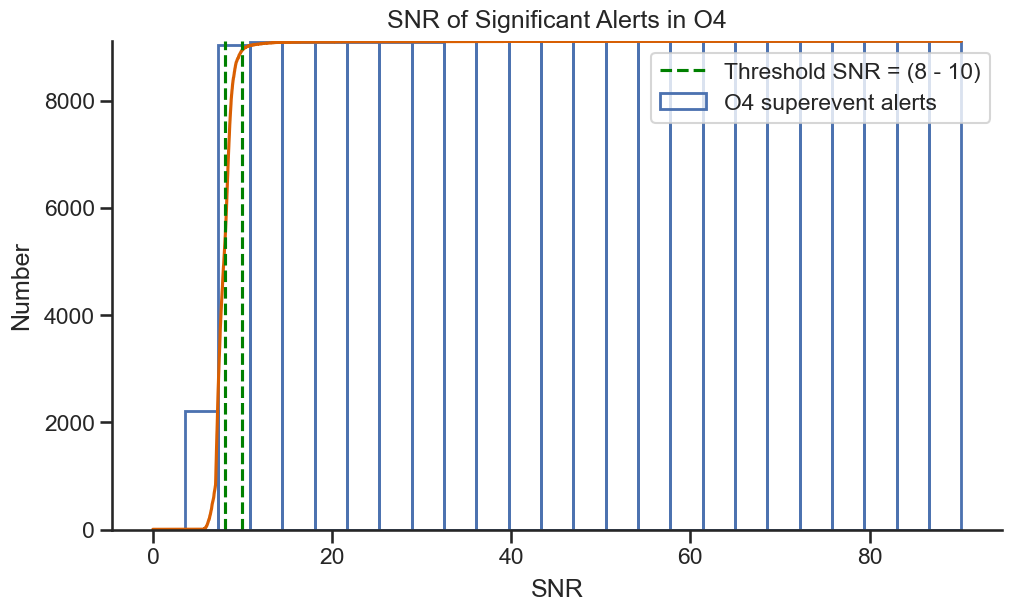

In [12]:
sns.set_theme(
    style="ticks",
    context="talk",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlepad": 10,
        "axes.labelpad": 8,
    },
)

colors = {"gwtc4": "#1b9e77", "o4alert": "#d95f02", "o4a": "#7570b3", "thresh": "navy"}


fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)  # plus grand
plt.rcParams["figure.dpi"] = 150

# cumulative histogram of O4 superevents alerts
sns.histplot(
    SNR_superevents_O4a_alert,
    stat="count",
    cumulative=True,
    bins=25,
    fill=False,
    # color=colors["o4alert"],
    # alpha=0.1,
    label="O4 superevent alerts",
    ax=ax,
)
# ECDF O4 superevents alerts
sns.ecdfplot(SNR_superevents_O4a_alert, stat="count", color=colors["o4alert"], ax=ax)

# Vertical lines,  SNR=8 and SNR=10
ax.axvline(x=8, ls="--", color="green", label=r"Threshold SNR = (8 - 10)")
ax.axvline(x=10, ls="--", color="green")

ax.set_ylabel("Number")
ax.set_xlabel("SNR")
ax.set_title("SNR of Significant Alerts in O4")
ax.legend()

plt.show()

## SNR in GWTC-4: GWTC-4 vs Superevents in the O4a

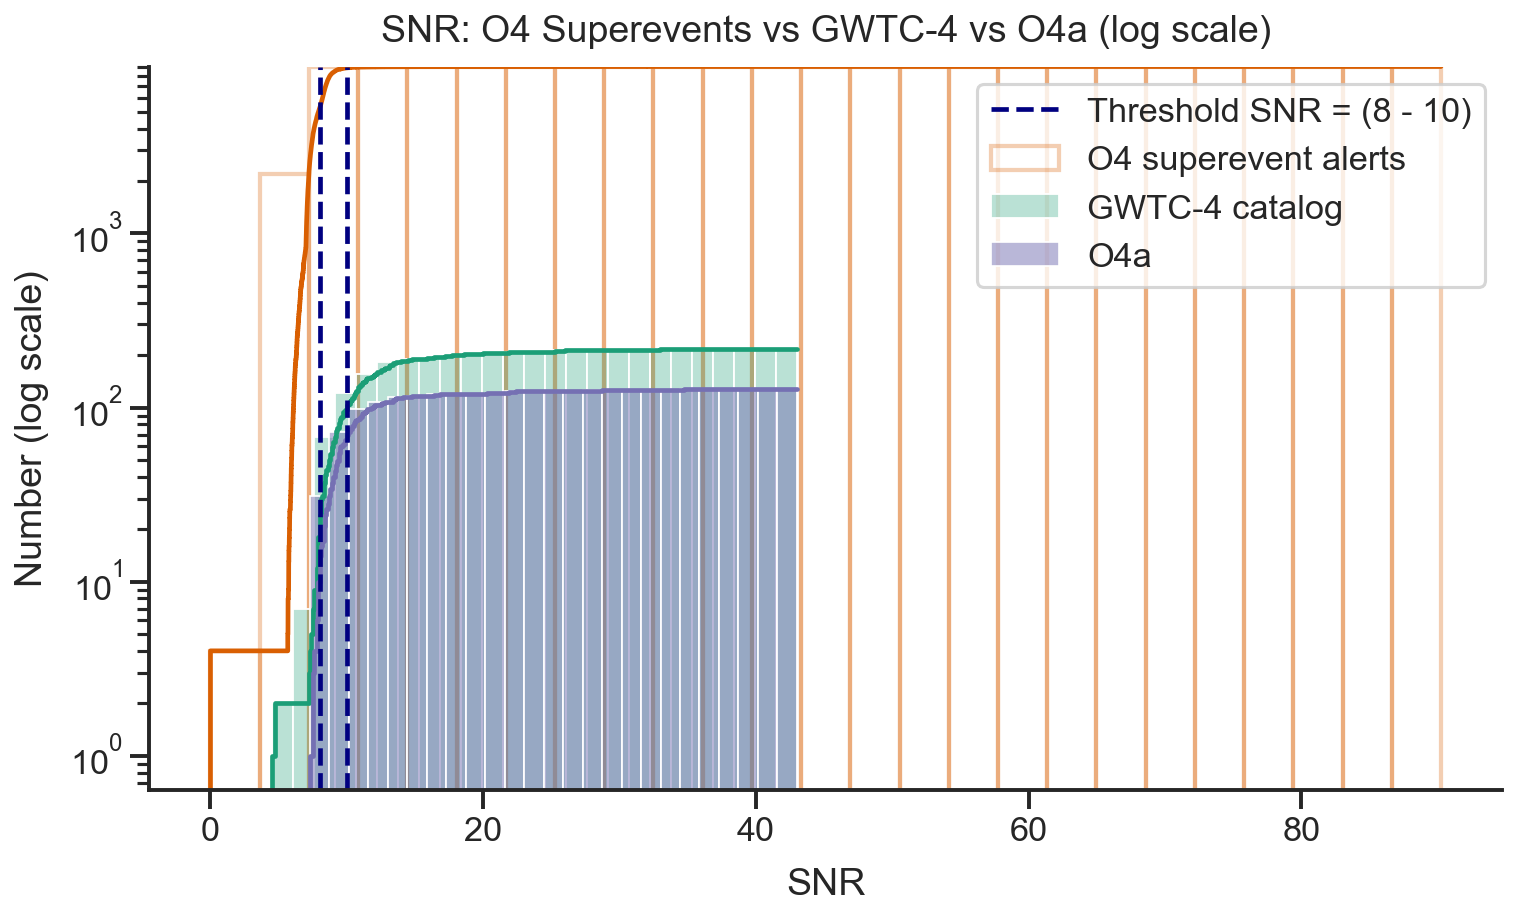

In [13]:
sns.set_theme(
    style="ticks",
    context="talk",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlepad": 12,
        "axes.labelpad": 10,
    },
)

colors = {"gwtc4": "#1b9e77", "o4alert": "#d95f02", "o4a": "#7570b3", "thresh": "navy"}

# plt.clf()
# fig, ax = plt.subplots(tight_layout=True)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)  # plus grand
plt.rcParams["figure.dpi"] = 150

# cumulative histogram of O4 superevents alerts
sns.histplot(
    SNR_superevents_O4a_alert,
    stat="count",
    cumulative=True,
    bins=25,
    fill=False,
    color=colors["o4alert"],
    alpha=0.3,
    label="O4 superevent alerts",
    ax=ax,
)
# ECDF O4 superevents alerts
sns.ecdfplot(SNR_superevents_O4a_alert, stat="count", color=colors["o4alert"], ax=ax)


# GWTC-4 cumulative histogram
sns.histplot(
    SNR_GWTC4,
    stat="count",
    cumulative=True,
    bins=25,
    fill=True,
    color=colors["gwtc4"],
    alpha=0.3,
    label="GWTC-4 catalog",
    ax=ax,
)
# ECDF GWTC-4
sns.ecdfplot(SNR_GWTC4, stat="count", color=colors["gwtc4"], ax=ax)

# O4a cumulative histogram
sns.histplot(
    SNR_O4a,
    stat="count",
    cumulative=True,
    bins=25,
    fill=True,
    color=colors["o4a"],
    alpha=0.5,
    label="O4a",
    ax=ax,
)
# ECDF O4a
sns.ecdfplot(SNR_O4a, stat="count", color=colors["o4a"], ax=ax)

# Vertical line SNR=8
ax.axvline(x=8, ls="--", color=colors["thresh"], label=r"Threshold SNR = (8 - 10)")
ax.axvline(x=10, ls="--", color=colors["thresh"])

ax.set_yscale("log")

ax.set_ylabel("Number (log scale)")
ax.set_xlabel("SNR")
ax.set_title("SNR: O4 Superevents vs GWTC-4 vs O4a (log scale)")
ax.legend()

plt.show()

## SNR in GWTC-4: GWTC-4 vs O4a Events

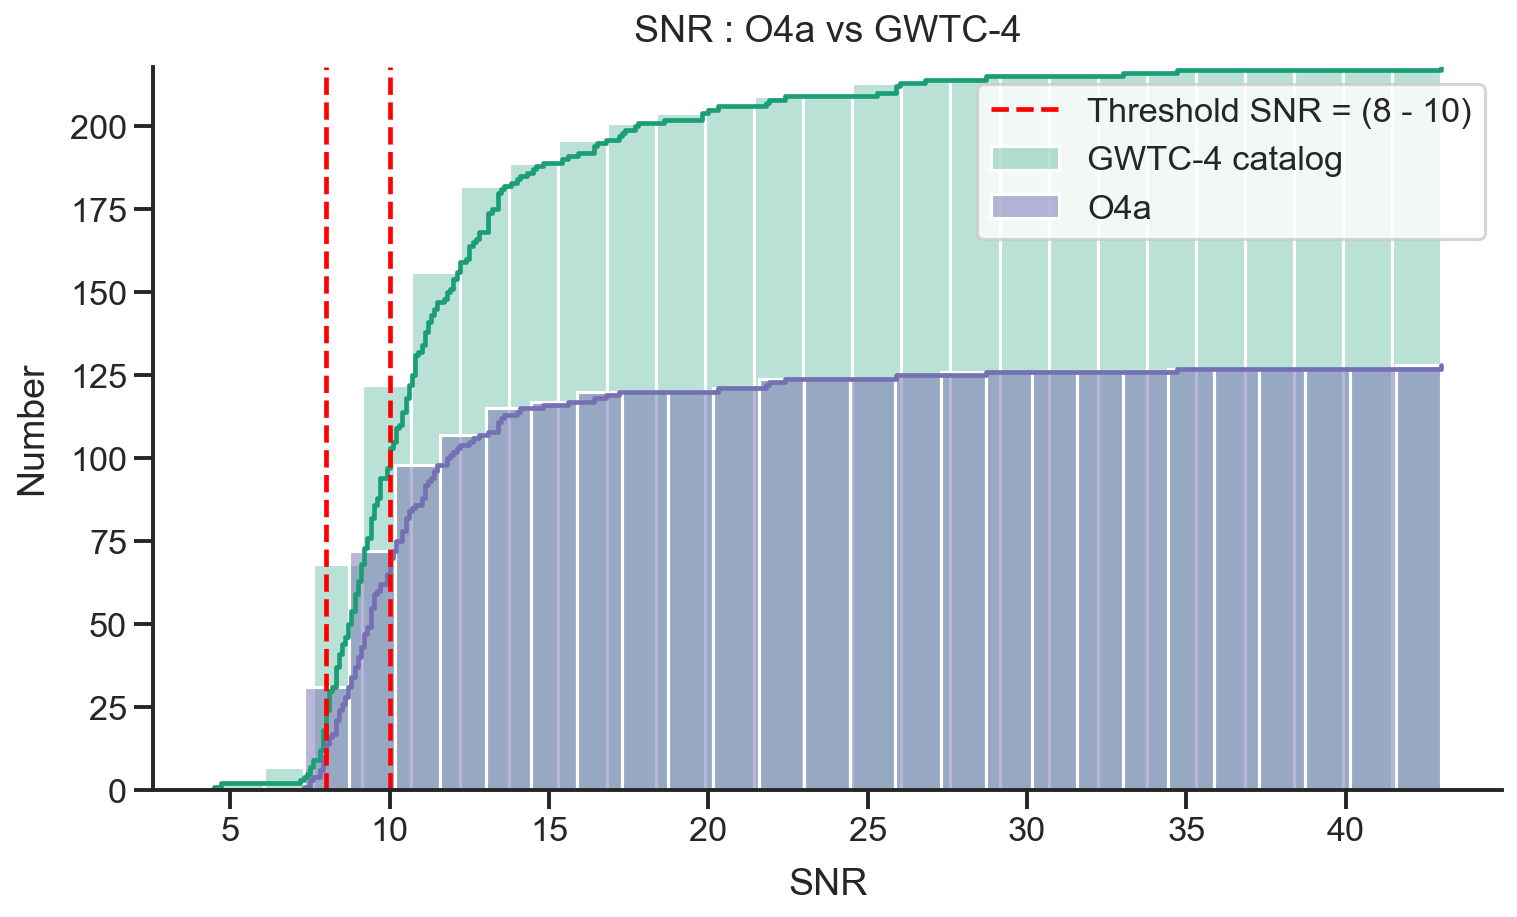

In [14]:
sns.set_theme(
    style="ticks",
    context="talk",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlepad": 12,
        "axes.labelpad": 10,
    },
)

colors = {"gwtc4": "#1b9e77", "o4alert": "#d95f02", "o4a": "#7570b3", "thresh": "navy"}

# plt.clf()
# fig, ax = plt.subplots(tight_layout=True)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)  # plus grand
plt.rcParams["figure.dpi"] = 150


# GWTC-4 cumulative histogram
sns.histplot(
    SNR_GWTC4,
    stat="count",
    cumulative=True,
    bins=25,
    fill=True,
    color=colors["gwtc4"],
    alpha=0.3,
    label="GWTC-4 catalog",
    ax=ax,
)
# ECDF GWTC-4
sns.ecdfplot(SNR_GWTC4, stat="count", color=colors["gwtc4"], ax=ax)

# O4a cumulative histogram
sns.histplot(
    SNR_O4a,
    stat="count",
    cumulative=True,
    bins=25,
    fill=True,
    color=colors["o4a"],
    alpha=0.5,
    label="O4a",
    ax=ax,
)
# ECDF O4a
sns.ecdfplot(SNR_O4a, stat="count", color=colors["o4a"], ax=ax)

# Vertical line SNR=8
ax.axvline(x=8, ls="--", color="red", label=r"Threshold SNR = (8 - 10)")
ax.axvline(x=10, ls="--", color="red")

ax.set_ylabel("Number")
ax.set_xlabel("SNR")
ax.set_title("SNR : O4a vs GWTC-4")
ax.legend()

plt.show()